In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import glob

In [26]:
#load scores as df
cher_scores = pd.read_csv('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/gmm_analysis/gmmdemux_scores.csv')
brian_scores = pd.read_csv('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/gmm_analysis/brian_gmmd_scores.csv')

In [27]:
cher_scores

,dataset,method,f1_micro,f1_macro,f1_weighted,mcc,concordance
0,mcginnis_ms,gmmdemux,0.962939,0.944776,0.966210,0.947187,0.952688
1,mcginnis_ab,gmmdemux,0.026534,0.006022,0.001797,-0.008947,0.024731
2,bar11,gmmdemux,0.627765,0.610347,0.627323,0.524482,0.480778
3,gaublomme,gmmdemux,0.913236,0.866750,0.892974,0.891541,0.902313
4,howitt_capture1,gmmdemux,0.348519,0.354628,0.345969,0.232012,0.226533
5,howitt_capture2,gmmdemux,0.372640,0.376849,0.372809,0.257219,0.245225
6,howitt_capture3,gmmdemux,0.290705,0.286625,0.290085,0.215437,0.180273
7,howitt_batch1_c1,gmmdemux,0.855553,0.848304,0.866619,0.789462,0.803351
8,howitt_batch1_c2,gmmdemux,0.844923,0.845209,0.851040,0.770774,0.784687
9,howitt_batch2_c1,gmmdemux,0.485291,0.486192,0.476474,0.391582,0.330144


In [28]:
brian_scores

,dataset,method,f1_micro,f1_macro,f1_weighted,mcc,concordance
0,mcginnis_ms,gmmdemux,0.962939,0.944776,0.966210,0.947187,0.952688
1,mcginnis_ab,gmmdemux,0.028245,0.006388,0.001906,-0.004309,0.026022
2,bar11,gmmdemux,0.578140,0.564551,0.577372,0.481861,0.425757
3,gaublomme,gmmdemux,0.913236,0.866750,0.892974,0.891541,0.902313
4,howitt_capture1,gmmdemux,0.213347,0.224009,0.188363,0.135731,0.128088
5,howitt_capture2,gmmdemux,0.208717,0.232146,0.185710,0.149359,0.124255
6,howitt_capture3,gmmdemux,0.135266,0.159685,0.121506,0.112065,0.077376
7,howitt_batch1_c1,gmmdemux,0.855553,0.848304,0.866619,0.789462,0.803351
8,howitt_batch1_c2,gmmdemux,0.844764,0.845055,0.850872,0.770659,0.784607
9,howitt_batch2_c1,gmmdemux,0.315457,0.324347,0.307102,0.257734,0.199334


In [32]:
#calculate absolute diffs for metrics
merged = cher_scores.merge(brian_scores, on=['dataset', 'method'], suffixes=('_cher', '_brian'))

for metric in ['f1_micro', 'f1_macro', 'f1_weighted', 'mcc', 'concordance']:
    merged[f'{metric}_diff'] = (merged[f'{metric}_cher'] - merged[f'{metric}_brian']).abs()

diff_cols = ['dataset'] + [f'{m}_diff' for m in ['f1_micro', 'f1_macro', 'f1_weighted', 'mcc', 'concordance']]

merged[diff_cols]

,dataset,f1_micro_diff,f1_macro_diff,f1_weighted_diff,mcc_diff,concordance_diff
0,mcginnis_ms,0.000000,0.000000,0.000000,0.000000,0.000000
1,mcginnis_ab,0.001710,0.000366,0.000109,0.004637,0.001290
2,bar11,0.049624,0.045796,0.049951,0.042621,0.055022
3,gaublomme,0.000000,0.000000,0.000000,0.000000,0.000000
4,howitt_capture1,0.135173,0.130619,0.157606,0.096281,0.098446
5,howitt_capture2,0.163923,0.144703,0.187098,0.107860,0.120969
6,howitt_capture3,0.155438,0.126940,0.168579,0.103372,0.102897
7,howitt_batch1_c1,0.000000,0.000000,0.000000,0.000000,0.000000
8,howitt_batch1_c2,0.000159,0.000154,0.000168,0.000115,0.000080
9,howitt_batch2_c1,0.169835,0.161845,0.169371,0.133847,0.130809


In [33]:
#summary stats of diffs
merged[diff_cols].describe()

,f1_micro_diff,f1_macro_diff,f1_weighted_diff,mcc_diff,concordance_diff
count,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.110599,0.104631,0.118241,0.083745,0.096005
std,0.143076,0.139055,0.152537,0.111436,0.134746
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000159,0.000154,0.000109,0.000115,0.000080
50%,0.049624,0.045796,0.049951,0.042621,0.055022
75%,0.163923,0.144703,0.169371,0.107860,0.120969
max,0.474181,0.465432,0.507149,0.376895,0.452391


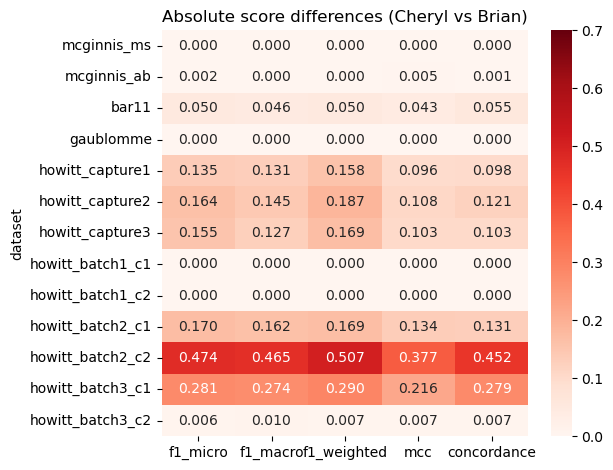

In [43]:
metrics = ['f1_micro', 'f1_macro', 'f1_weighted', 'mcc', 'concordance']
diff_pivot = merged.set_index('dataset')[[f'{m}_diff' for m in metrics]]
diff_pivot.columns = metrics

sns.heatmap(diff_pivot, annot=True, fmt='.3f', cmap='Reds', vmin=0, vmax=0.7)
plt.title('Absolute score differences (Cheryl vs Brian)')
plt.tight_layout()
#plt.savefig('analysis/gmm_analysis/diff_heatmap.pdf')
plt.show()

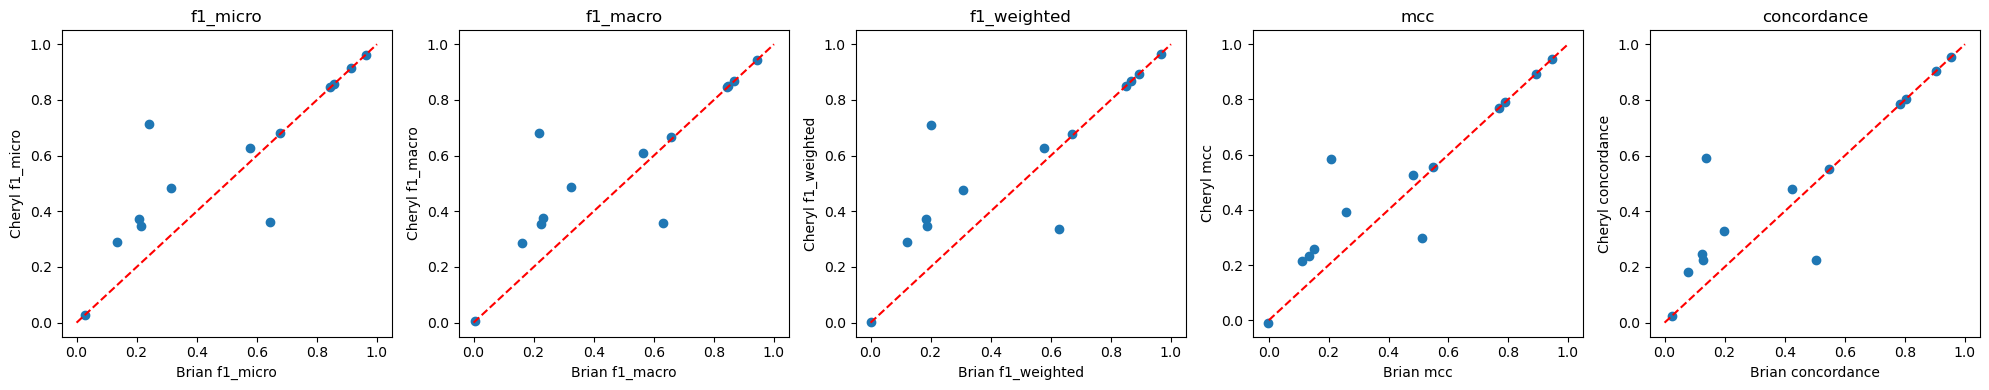

In [ ]:
#scatterplot
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, metric in zip(axes, metrics):
    ax.scatter(merged[f'{metric}_brian'], merged[f'{metric}_cher'])
    ax.plot([0, 1], [0, 1], 'r--')  #line for perfect matches
    ax.set_xlabel(f'Brian {metric}')
    ax.set_ylabel(f'Cheryl {metric}')
    ax.set_title(metric)

plt.tight_layout()
plt.savefig('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/gmm_analysis/score_comparison.pdf')
plt.show()